In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

df = pd.read_csv("D:/DATA/aitpune/college study thingy/dsbdal/prac_exam_questions/10-naive-bayes-iris/Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
df = df.drop("Id", axis=1)

In [3]:
df.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [4]:
X = df.drop("Species", axis=1)
y = df["Species"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [7]:
y_pred = model.predict(X_test)

In [8]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [9]:
# Convert to binary (Setosa vs Rest)
y_test_bin = (y_test == "Iris-setosa").astype(int)
y_pred_bin = (y_pred == "Iris-setosa").astype(int)

cm_bin = confusion_matrix(y_test_bin, y_pred_bin)

TN, FP, FN, TP = cm_bin.ravel()

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

TN: 20
FP: 0
FN: 0
TP: 10


In [10]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0


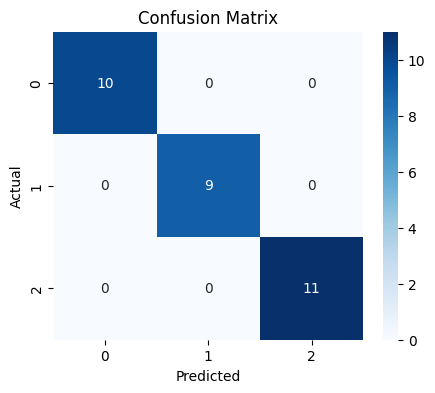

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()